# Samara five-model speller comparison (Colab)

Within-subject character benchmark on Samara P300 data: train **SVM, EEGNet, BaseCNN, ContextualTransformer, SequenceClassifier**, run the speller benchmark, and compare `char_acc(r)` curves.

**SequenceClassifier** is character-level, so this notebook trains **one checkpoint per `r`** and evaluates each only at that same `r`. Flash scorers (SVM / EEGNet / BaseCNN / ContextualTransformer) are still trained once and decoded at every `r` — extra repeats there are score accumulation, not a new sequence length.

Design spec: [`docs/superpowers/specs/2026-08-11-samara-colab-speller-compare-design.md`](../../docs/superpowers/specs/2026-08-11-samara-colab-speller-compare-design.md).

Absolute imports only: `from pattern_recognition...`. Requires Samara `.mat` files (no synthetic fallback).

## Colab setup (optional locally)

Use a **GPU** runtime. One install command is enough on Colab Python 3.12 (core deps accept Colab’s Torch / NumPy 2.x). Skip this section when the package is already installed locally.

GNN / viz extras (historical notebooks only): `pip install -e ".[gnn,viz]"`.


In [1]:
# Mount Drive first if the repo / Samara_data live there
from google.colab import drive

drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# One-command install (core package for runner / speller / CNN+SVM).
# Prefer a Drive clone so `configs/` is on disk for this notebook.
%cd /content/drive/MyDrive/pattern_recognition
!pip install -q -e .

# Or, without a local clone (package only — you still need configs elsewhere):
# !pip install -q "git+https://github.com/Sidl419/pattern_recognition.git"


/content/drive/MyDrive/pattern_recognition
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building editable for pattern-recognition (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Building editable for pattern-recognition (pyproject.toml) ... error
  ERROR: Failed building editable for pattern-recognition
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (pattern-recognition)


In [3]:
import pattern_recognition, mne, torch
print(pattern_recognition.__file__)
print("mne", mne.__version__, "torch", torch.__version__)

/content/pattern_recognition/pattern_recognition/__init__.py
mne 1.12.1 torch 2.11.0+cu128


## Paths and settings

In [4]:
from pathlib import Path
import json
import copy

REPO_ROOT = Path(".").resolve()
if not (REPO_ROOT / "configs").is_dir() and (REPO_ROOT.parent.parent / "configs").is_dir():
    REPO_ROOT = REPO_ROOT.parent.parent

SAMARA_PATH = REPO_ROOT / "Samara_data"  # override on Colab, e.g. Drive path
NUM_EPOCHS = 250
DEVICE = "auto"
OUTPUT_DIR = REPO_ROOT / "results"
REPETITIONS = [1, 2, 5, 10]  # SequenceClassifier trains and evals at each r

print("repo root:", REPO_ROOT)
print("Samara path:", SAMARA_PATH)
print("repetitions:", REPETITIONS)

repo root: /content/drive/MyDrive/pattern_recognition
Samara path: /content/drive/MyDrive/pattern_recognition/Samara_data


## Sanity check — Samara data required

In [5]:
if not SAMARA_PATH.is_dir() or not any(SAMARA_PATH.glob("*.mat")):
    raise FileNotFoundError(
        f"Samara .mat files not found under {SAMARA_PATH}. "
        "Mount Drive or set SAMARA_PATH to your Samara_data directory."
    )
print(f"Found {len(list(SAMARA_PATH.glob('*.mat')))} .mat files in {SAMARA_PATH}")

Found 20 .mat files in /content/drive/MyDrive/pattern_recognition/Samara_data


## Train models

Flash scorers (SVM, EEGNet, BaseCNN, ContextualTransformer) train once. **SequenceClassifier trains four times**, with `data.params.r_max` set to each value in `REPETITIONS`, so train packet length matches the later eval `r`.

Flash scorers (SVM, EEGNet, BaseCNN) use `SamaraWithinSubjectAverage` with `n_average=1`. ContextualTransformer and SequenceClassifier use `SamaraSelectionPackets`. Neural models train for `NUM_EPOCHS` (default 250); SVM fits in one shot.

In [6]:
from pattern_recognition.experiment import run_experiment

NEURAL_MODELS = {"EEGNet", "BaseCNN", "ContextualTransformer", "SequenceClassifier"}

FLASH_TRAIN_CONFIGS = {
    "SVM": "samara_pz_svm_sc_n1.json",
    "EEGNet": "samara_pz_eegnet_sc_n1.json",
    "BaseCNN": "samara_pz_basecnn_sc_n1.json",
    "ContextualTransformer": "samara_contextual_transformer.json",
}
SC_TRAIN_CONFIG = "samara_sequence_classifier.json"


def prepare_train_config(cfg: dict, model_name: str) -> dict:
    cfg = copy.deepcopy(cfg)
    cfg["device"] = DEVICE
    cfg["output_dir"] = str(OUTPUT_DIR)
    if "data" in cfg and "params" in cfg["data"]:
        cfg["data"]["params"]["path"] = str(SAMARA_PATH)
    if model_name in NEURAL_MODELS and "train" in cfg:
        cfg["train"]["num_epochs"] = NUM_EPOCHS
    return cfg


run_dirs = {}
for name, fname in FLASH_TRAIN_CONFIGS.items():
    cfg = json.loads((REPO_ROOT / "configs" / fname).read_text())
    cfg = prepare_train_config(cfg, name)
    print(f"Training {name} ...")
    run_dirs[name] = run_experiment(cfg)
    print(f"  -> {run_dirs[name]}")

sc_run_dirs = {}
sc_template = json.loads((REPO_ROOT / "configs" / SC_TRAIN_CONFIG).read_text())
for r in REPETITIONS:
    cfg = prepare_train_config(sc_template, "SequenceClassifier")
    cfg["name"] = f"samara_sequence_classifier_r{r}"
    cfg["data"]["params"]["r_max"] = r
    print(f"Training SequenceClassifier at r={r} ...")
    sc_run_dirs[r] = run_experiment(cfg)
    print(f"  -> {sc_run_dirs[r]}")

Training SVM ...
  -> /content/drive/MyDrive/pattern_recognition/results/samara_pz_svm_sc_n1_20260823_114819
Training EEGNet ...
Training complete in 14m 43s
  -> /content/drive/MyDrive/pattern_recognition/results/samara_pz_eegnet_sc_n1_20260823_122458
Training BaseCNN ...
Training complete in 12m 55s
  -> /content/drive/MyDrive/pattern_recognition/results/samara_pz_basecnn_sc_n1_20260823_123947
Training ContextualTransformer ...


/content/pattern_recognition/pattern_recognition/models/cnn.py:366: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


  -> /content/drive/MyDrive/pattern_recognition/results/samara_contextual_transformer_20260823_125248
Training SequenceClassifier ...


/content/pattern_recognition/pattern_recognition/models/cnn.py:366: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


  -> /content/drive/MyDrive/pattern_recognition/results/samara_sequence_classifier_20260823_125358


## Speller benchmark

Flash scorers use `flash_scorer` and are decoded at every `r` in `REPETITIONS`. Each SequenceClassifier checkpoint uses `selection_classifier` and is decoded **only at the `r` it was trained on**. All runs share phrase `JUST_DO_IT`.

In [7]:
from pattern_recognition.speller import run_speller_benchmark

FLASH_SPELLER = {
    "SVM": ("flash_scorer", "speller_samara_flash_n1.json"),
    "EEGNet": ("flash_scorer", "speller_samara_flash_n1.json"),
    "BaseCNN": ("flash_scorer", "speller_samara_flash_n1.json"),
    "ContextualTransformer": ("flash_scorer", "speller_samara_contextual.json"),
}
SC_SPELLER_CONFIG = "speller_samara_sequence_classifier.json"


def prepare_speller_config(
    cfg: dict, *, run_dir, model_mode: str, tag: str, repetitions: list[int]
) -> dict:
    cfg = copy.deepcopy(cfg)
    cfg["run_dir"] = str(run_dir)
    cfg["model_mode"] = model_mode
    cfg["tag"] = tag
    cfg["repetitions"] = list(repetitions)
    if "protocol_params" in cfg:
        cfg["protocol_params"]["path"] = str(SAMARA_PATH)
    return cfg


speller_dirs = {}
for name, run_dir in run_dirs.items():
    mode, fname = FLASH_SPELLER[name]
    cfg = json.loads((REPO_ROOT / "configs" / fname).read_text())
    cfg = prepare_speller_config(
        cfg,
        run_dir=run_dir,
        model_mode=mode,
        tag=f"compare_{name.lower()}",
        repetitions=REPETITIONS,
    )
    print(f"Speller {name} ({mode}) ...")
    speller_dirs[name] = run_speller_benchmark(cfg)
    print(f"  -> {speller_dirs[name]}")

sc_speller_dirs = {}
sc_speller_template = json.loads((REPO_ROOT / "configs" / SC_SPELLER_CONFIG).read_text())
for r, run_dir in sc_run_dirs.items():
    cfg = prepare_speller_config(
        sc_speller_template,
        run_dir=run_dir,
        model_mode="selection_classifier",
        tag=f"compare_sequenceclassifier_r{r}",
        repetitions=[r],
    )
    print(f"Speller SequenceClassifier r={r} (selection_classifier) ...")
    sc_speller_dirs[r] = run_speller_benchmark(cfg)
    print(f"  -> {sc_speller_dirs[r]}")

Speller SVM (flash_scorer) ...
  -> /content/drive/MyDrive/pattern_recognition/results/samara_pz_svm_sc_n1_20260823_114819/speller/compare_svm
Speller EEGNet (flash_scorer) ...
  -> /content/drive/MyDrive/pattern_recognition/results/samara_pz_eegnet_sc_n1_20260823_122458/speller/compare_eegnet
Speller BaseCNN (flash_scorer) ...
  -> /content/drive/MyDrive/pattern_recognition/results/samara_pz_basecnn_sc_n1_20260823_123947/speller/compare_basecnn
Speller ContextualTransformer (flash_scorer) ...


/content/pattern_recognition/pattern_recognition/models/cnn.py:366: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


  -> /content/drive/MyDrive/pattern_recognition/results/samara_contextual_transformer_20260823_125248/speller/compare_contextualtransformer
Speller SequenceClassifier (selection_classifier) ...


/content/pattern_recognition/pattern_recognition/models/cnn.py:366: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


  -> /content/drive/MyDrive/pattern_recognition/results/samara_sequence_classifier_20260823_125358/speller/compare_sequenceclassifier


## Compare results

Pooled `char_acc(r)` plus ITR. SequenceClassifier points are **matched-r** (four models). The dashed line is chance on the 4×4 grid (`1/16`). Error bars are the standard deviation across subjects.

model,BaseCNN,ContextualTransformer,EEGNet,SVM,SequenceClassifier
r,,,,,
1,0.15,0.26,0.20,0.10,0.21
2,0.19,0.38,0.27,0.15,0.17
5,0.27,0.30,0.28,0.22,0.20
10,0.33,0.36,0.38,0.27,0.20


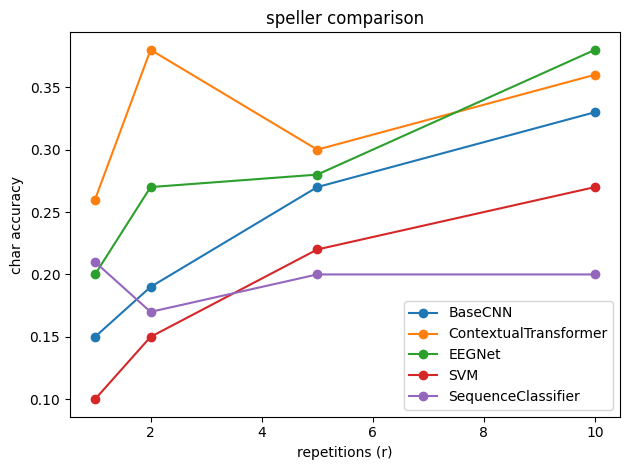


Binary training metrics:


,name,device_resolved,model.name,data.pipeline,accuracy,balanced_accuracy,f1,brier,itr,train_time_sec,mode,n_average
0,samara_pz_svm_sc_n1,cuda:0,SVM,SamaraWithinSubjectAverage,0.938133,0.503390,0.013468,0.114346,0.665190,2156.953907,SC,1.0
1,samara_pz_eegnet_sc_n1,cuda:0,EEGNet,SamaraWithinSubjectAverage,0.939295,0.513503,0.052718,0.111503,0.669762,883.099407,SC,1.0
2,samara_pz_basecnn_sc_n1,cuda:0,BaseCNN,SamaraWithinSubjectAverage,0.937711,0.500000,0.000000,0.115046,0.663535,775.170955,SC,1.0
3,samara_contextual_transformer,cuda:0,ContextualTransformer,SamaraSelectionPackets,0.696187,0.730633,0.240587,0.371431,0.114099,63.674874,NaN,NaN
4,samara_sequence_classifier,cuda:0,SequenceClassifier,SamaraSelectionPackets,0.200000,NaN,NaN,0.860509,0.152559,59.228182,NaN,NaN


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

from pattern_recognition.reporting import load_run, metrics_table

CHANCE = 1 / 16


def _acc_rows(speller_dir, model: str) -> list[dict]:
    metrics = json.loads((speller_dir / "speller_metrics.json").read_text())
    n_sel = metrics.get("n_selections")
    return [
        {
            "model": model,
            "r": point["r"],
            "char_acc": point["char_acc"],
            "itr": point["itr"],
            "n_selections": n_sel,
        }
        for point in metrics["acc_vs_repeats"]
    ]


rows = []
for name, speller_dir in speller_dirs.items():
    rows.extend(_acc_rows(speller_dir, name))
for r, speller_dir in sc_speller_dirs.items():
    rows.extend(_acc_rows(speller_dir, "SequenceClassifier"))

char_acc_table = pd.DataFrame(rows)
pivot = char_acc_table.pivot(index="r", columns="model", values="char_acc")
itr_pivot = char_acc_table.pivot(index="r", columns="model", values="itr")
try:
    display(pivot)
except NameError:
    print(pivot)

per_frames = []
for name, speller_dir in speller_dirs.items():
    frame = pd.read_csv(speller_dir / "per_subject.csv")
    frame["model"] = name
    per_frames.append(frame)
for r, speller_dir in sc_speller_dirs.items():
    frame = pd.read_csv(speller_dir / "per_subject.csv")
    frame["model"] = "SequenceClassifier"
    per_frames.append(frame)
per_subject = pd.concat(per_frames, ignore_index=True)
subj_stats = (
    per_subject.groupby(["model", "r"], as_index=False)["char_acc"]
    .agg(mean="mean", std="std", n_subjects="count")
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for model, group in subj_stats.groupby("model"):
    group = group.sort_values("r")
    axes[0].errorbar(
        group["r"],
        group["mean"],
        yerr=group["std"].fillna(0.0),
        marker="o",
        capsize=3,
        label=model,
    )
axes[0].axhline(CHANCE, linestyle="--", color="0.5", label="chance (1/16)")
axes[0].set_xlabel("repetitions (r)")
axes[0].set_ylabel("char accuracy")
axes[0].set_title("char acc (mean ± std across subjects)")
axes[0].set_xticks(REPETITIONS)
axes[0].legend(fontsize=8)

for model in itr_pivot.columns:
    axes[1].plot(itr_pivot.index, itr_pivot[model], marker="o", label=model)
axes[1].set_xlabel("repetitions (r)")
axes[1].set_ylabel("ITR (bits/min)")
axes[1].set_title("ITR vs repetitions")
axes[1].set_xticks(REPETITIONS)
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

print("SequenceClassifier: train r == eval r. Flash models: one checkpoint, decoded at every r.")
print(f"n_selections (flash run): {int(char_acc_table.dropna(subset=['n_selections'])['n_selections'].iloc[0])}")

train_dirs = list(run_dirs.values()) + [sc_run_dirs[r] for r in REPETITIONS]
binary_table = metrics_table(train_dirs)
print("\nTraining metrics (SC rows are selection accuracy, not flash accuracy):")
try:
    display(binary_table)
except NameError:
    print(binary_table)

In [ ]:
# Extra diagnostics: per-subject table, and SC val accuracy vs matched-r speller acc.
print("Per-subject mean ± std:")
try:
    display(subj_stats.sort_values(["model", "r"]))
except NameError:
    print(subj_stats.sort_values(["model", "r"]))

sc_check = []
for r, run_dir in sc_run_dirs.items():
    run = load_run(run_dir)
    matched = char_acc_table[
        (char_acc_table["model"] == "SequenceClassifier") & (char_acc_table["r"] == r)
    ]
    sc_check.append(
        {
            "r": r,
            "val_accuracy": run.metrics.get("accuracy"),
            "speller_char_acc": float(matched["char_acc"].iloc[0]),
            "n_selections": int(matched["n_selections"].iloc[0]),
            "run": Path(run_dir).name,
        }
    )
sc_check_table = pd.DataFrame(sc_check)
print("\nSequenceClassifier sanity (val packets vs holdout speller, same r):")
try:
    display(sc_check_table)
except NameError:
    print(sc_check_table)

subject_pivot = per_subject.pivot_table(
    index="subject", columns=["model", "r"], values="char_acc"
)
print("\nPer-subject char_acc:")
try:
    display(subject_pivot)
except NameError:
    print(subject_pivot)